In [2]:
# Imports & seed
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib
import math

# Reproducibility (not perfect but helps)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Load data (tự động chọn cột target)
DATA_PATH = r"D:\lecture\PTIT\20251\IntSys\diabetes.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

# Tìm cột target: ưu tiên 'Outcome', 'target', 'y' rồi cột cuối
possible_targets = ['Outcome', 'outcome', 'target', 'Target', 'y', 'Y']
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break
if target_col is None:
    target_col = df.columns[-1]   # fallback: last column

print("Chọn cột target:", target_col)

# Chuẩn bị X, y
# Nếu cột target là dạng categorical/labels cho classification, file could be Pima dataset (0/1).
# Tuy nhiên yêu cầu dùng metrics MAE/MSE/RMSE => ta xử lý bài toán regression.
# Nếu target chỉ có 0/1, ta vẫn dùng regression metrics (vẫn có ý nghĩa) hoặc bạn có thể chuyển sang classification.

X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy().astype(float)

print("X shape:", X.shape, "y shape:", y.shape)
display(X.describe().T)

# Kiểm tra missing và xử lý
print("Missing per col:")
print(X.isnull().sum())

# Nếu có missing -> điền median
if X.isnull().any().any():
    X = X.fillna(X.median())
    print("Đã fillna bằng median.")

# Train/Val/Test split + scaling
# Split: train 70%, val 15%, test 15%
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176470588, random_state=SEED)
# tỉ lệ trên để X_train ~70% tổng, X_val ~15%, X_test ~15%

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Chọn cột target: Outcome
X shape: (768, 8) y shape: (768,)


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


Missing per col:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
Train: (536, 8) Val: (116, 8) Test: (116, 8)




===== Training model_A_7layers =====


C:\Python313\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 69,505 (271.50 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 512)                 │           4,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 266,337 (1.02 MB)

 Trainable params: 266,337 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.3366 - mae: 0.3496 - val_loss: 0.3586 - val_mae: 0.3951 - learning_rate: 0.0010
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.3092 - mae: 0.3604 - val_loss: 0.3214 - val_mae: 0.4074 - learning_rate: 0.0010
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2807 - mae: 0.3818 - val_loss: 0.2834 - val_mae: 0.4204 - learning_rate: 0.0010
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2620 - mae: 0.3969 - val_loss: 0.2746 - val_mae: 0.4274 - learning_rate: 0.0010
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2583 - mae: 0.4098 - val_loss: 0.2641 - val_mae: 0.4322 - learning_rate: 0.0010
Epoch 6/200
12/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2711 - mae: 0.4367 
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2430 - mae: 0.4110 - val_loss: 0.2501 - val_mae: 0.4319 - learning_rate: 0.0010
Epoc

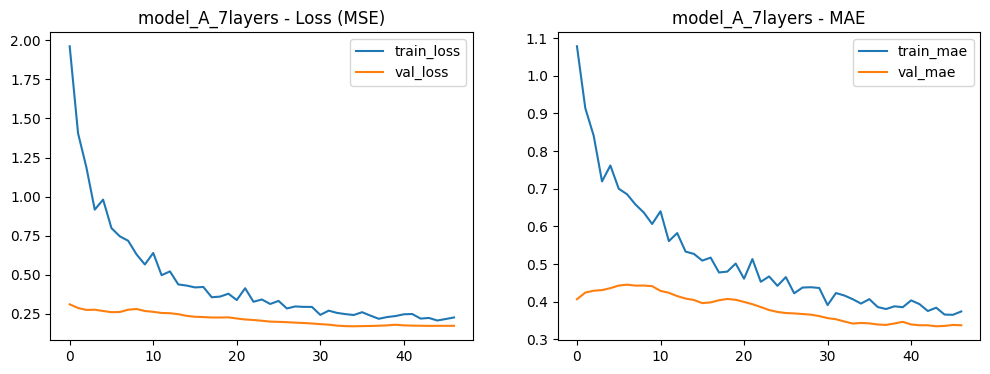

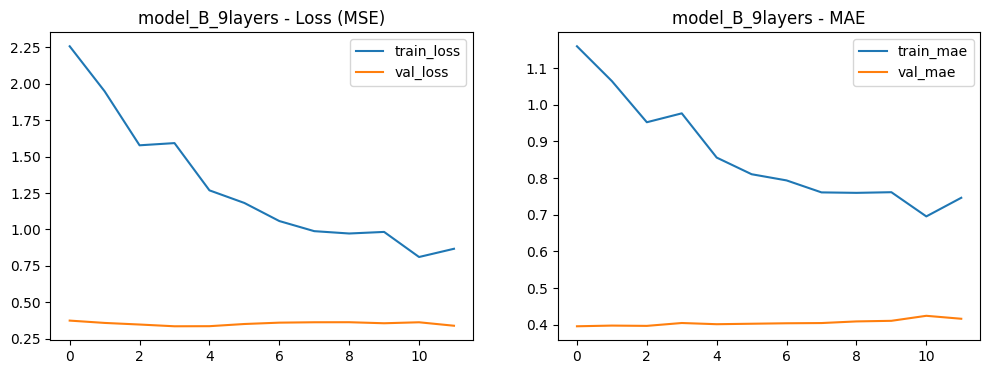

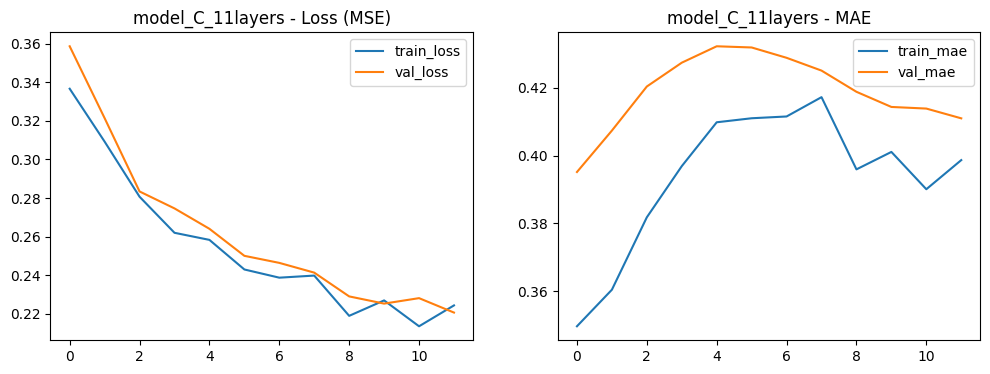

In [3]:
# Hàm xây dựng model theo số layers & neurons
def build_dense_model(input_dim, neurons_list, dropout_rate=0.2, use_batchnorm=False):
    """
    neurons_list: list of integers => số neuron mỗi Dense layer (ví dụ [128,64,64,32,32,16,8] => 7 layers)
    Tất cả layers => Dense + (BatchNorm) + ReLU + Dropout (optional)
    Output layer: 1 neuron (regression)
    """
    model = Sequential()
    for i, n in enumerate(neurons_list):
        if i == 0:
            model.add(Dense(n, input_dim=input_dim, activation='relu'))
        else:
            model.add(Dense(n, activation='relu'))
        if use_batchnorm:
            model.add(BatchNormalization())
        if dropout_rate and dropout_rate>0:
            model.add(Dropout(dropout_rate))
    # output
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Định nghĩa 3 kiến trúc (tất cả >=7 dense layers trước output)
input_dim = X_train_scaled.shape[1]

models_config = {
    "model_A_7layers": {
        "neurons":[256, 128, 128, 64, 64, 32, 16],  # 7 layers
        "dropout": 0.2,
        "batchnorm": True
    },
    "model_B_9layers": {
        "neurons":[256, 256, 128, 128, 64, 64, 32, 16, 8],  # 9 layers
        "dropout": 0.25,
        "batchnorm": True
    },
    "model_C_11layers": {
        "neurons":[512, 256, 256, 128, 128, 64, 64, 32, 16, 8, 4],  # 11 layers
        "dropout": 0.3,
        "batchnorm": False
    }
}

# Train các model, lưu history và đánh giá trên validation
histories = {}
trained_models = {}
results = {}

ES = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1)
RLR = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, verbose=1)

EPOCHS = 200
BATCH = 32

for name, cfg in models_config.items():
    print("\n\n===== Training", name, "=====")
    model = build_dense_model(input_dim, cfg["neurons"], dropout_rate=cfg["dropout"], use_batchnorm=cfg["batchnorm"])
    model.summary()
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=EPOCHS,
        batch_size=BATCH,
        callbacks=[ES, RLR],
        verbose=1
    )
    histories[name] = history
    trained_models[name] = model

    # Evaluate on validation
    val_pred = model.predict(X_val_scaled).ravel()
    val_mae = mean_absolute_error(y_val, val_pred)
    val_mse = mean_squared_error(y_val, val_pred)
    val_rmse = math.sqrt(val_mse)
    print(f"{name} - VAL MAE: {val_mae:.4f}, MSE: {val_mse:.4f}, RMSE: {val_rmse:.4f}")
    results[name] = {"val_mae": val_mae, "val_mse": val_mse, "val_rmse": val_rmse}

# Plot training/validation loss & MAE to check overfitting for each model
def plot_history(history, title=None):
    plt.figure(figsize=(12,4))
    # loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.title((title or "") + " - Loss (MSE)")
    plt.legend()
    # mae
    plt.subplot(1,2,2)
    plt.plot(history.history.get('mae',[]), label='train_mae')
    plt.plot(history.history.get('val_mae',[]), label='val_mae')
    plt.title((title or "") + " - MAE")
    plt.legend()
    plt.show()

for name, h in histories.items():
    plot_history(h, title=name)


In [4]:
# So sánh kết quả validation và chọn best theo RMSE thấp nhất
for name, metrics in results.items():
    print(name, metrics)

best_model_name = min(results.keys(), key=lambda k: results[k]['val_rmse'])
print("Best model on validation (by RMSE):", best_model_name)
best_model = trained_models[best_model_name]

# Đánh giá best model trên test set (final evaluation)
y_pred_test = best_model.predict(X_test_scaled).ravel()
test_mae = mean_absolute_error(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_rmse = math.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred_test)

print("Test MAE:", test_mae)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)

# Hiển thị một vài so sánh true vs pred
cmp = pd.DataFrame({"y_true": y_test.values, "y_pred": y_pred_test})
display(cmp.head(10))

# Lưu model & scaler để deployment
MODEL_DIR = "saved_model_diabetes"
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, "best_model.h5")
scaler_path = os.path.join(MODEL_DIR, "scaler.pkl")

best_model.save(model_path)
joblib.dump(scaler, scaler_path)
print("Saved model to", model_path)
print("Saved scaler to", scaler_path)


model_A_7layers {'val_mae': 0.34334475071779613, 'val_mse': 0.17054087648974348, 'val_rmse': 0.4129659507631876}
model_B_9layers {'val_mae': 0.3953473432278582, 'val_mse': 0.3744934403237927, 'val_rmse': 0.611958691680895}
model_C_11layers {'val_mae': 0.39513068800342493, 'val_mse': 0.3585834611501364, 'val_rmse': 0.5988183874516015}
Best model on validation (by RMSE): model_A_7layers
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Test MAE: 0.3603223028496422
Test MSE: 0.18664792303602398
Test RMSE: 0.43202768781181605
Test R2: 0.173837351193178


,y_true,y_pred
0,0.0,0.277230
1,0.0,0.011104
2,0.0,0.174906
3,0.0,0.343453
4,0.0,0.455221
5,0.0,0.508682
6,0.0,0.073505
7,0.0,0.390516
8,0.0,0.538767
9,0.0,0.410625


Saved model to saved_model_diabetes\best_model.h5
Saved scaler to saved_model_diabetes\scaler.pkl


In [1]:
import numpy as np
import joblib
from flask import Flask, request, render_template_string
from flask_ngrok import run_with_ngrok
import tensorflow as tf

# ===== Load model & scaler =====
MODEL_PATH = "saved_model_diabetes/best_model.h5"
SCALER_PATH = "saved_model_diabetes/scaler.pkl"

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
scaler = joblib.load(SCALER_PATH)

# ===== Flask app =====
app = Flask(__name__)
run_with_ngrok(app)  # để chạy được trong notebook

# ===== HTML inline (đơn giản, đủ dùng) =====
HTML = """
<!doctype html>
<html>
<head>
    <title>Diabetes Prediction</title>
</head>
<body>
    <h2>Dự báo bệnh tiểu đường</h2>
    <form method="post">
        {% for f in features %}
            <label>{{f}}</label><br>
            <input type="number" step="any" name="{{f}}" required><br><br>
        {% endfor %}
        <button type="submit">Dự báo</button>
    </form>

    {% if prediction is not none %}
        <h3>Kết quả dự báo: {{ prediction }}</h3>
    {% endif %}
</body>
</html>
"""

# ===== Route =====
@app.route("/", methods=["GET", "POST"])
def predict():
    prediction = None

    # Số feature phải khớp dữ liệu train
    feature_names = [
        "Pregnancies",
        "Glucose",
        "BloodPressure",
        "SkinThickness",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
    ]

    if request.method == "POST":
        values = [float(request.form[f]) for f in feature_names]
        X = np.array(values).reshape(1, -1)
        X_scaled = scaler.transform(X)
        y_pred = model.predict(X_scaled)[0][0]
        if y_pred >= 0.5:
            prediction = f"{y_pred:.4f} → Có nguy cơ mắc tiểu đường"
        else:
            prediction = f"{y_pred:.4f} → Không mắc tiểu đường"


    return render_template_string(
        HTML,
        features=feature_names,
        prediction=prediction
    )

# ===== Run =====
app.run()


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [14/Dec/2025 21:39:28] "GET / HTTP/1.1" 200 -
C:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step


127.0.0.1 - - [14/Dec/2025 21:40:19] "POST / HTTP/1.1" 200 -
